## Mental Health & Income Level: Exploratory Data Analysis

This notebook analyzes the cleaned, merged dataset to explore whether income level 
correlates with the burden of mental health disorders — looking at both prevalence 
(how common) and DALYs (how severe). Countries are grouped into World Bank income 
tiers, and one spotlight country per tier is selected for a closer look.

### Load the Cleaned Dataset

Loading the merged dataset produced in the cleaning notebook (01_data_exploration.ipynb).

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\ASUS\Documents\Mental Health Dashboard\data\ihme_income_merged.csv")
df.head()

,measure_name,location_name,cause_name,year,val,income_group
0,DALYs (Disability-Adjusted Life Years),Taiwan,Depressive disorders,1990,273.491663,High income
1,DALYs (Disability-Adjusted Life Years),Taiwan,Bipolar disorder,1990,50.045391,High income
2,DALYs (Disability-Adjusted Life Years),Taiwan,Anxiety disorders,1990,318.227840,High income
3,DALYs (Disability-Adjusted Life Years),Taiwan,Eating disorders,1990,54.418122,High income
4,DALYs (Disability-Adjusted Life Years),Cambodia,Schizophrenia,1990,130.170157,Lower middle income


In [13]:
print(df.shape)
df.info()

(69360, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69360 entries, 0 to 69359
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   measure_name   69360 non-null  object 
 1   location_name  69360 non-null  object 
 2   cause_name     69360 non-null  object 
 3   year           69360 non-null  int64  
 4   val            69360 non-null  float64
 5   income_group   68000 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 3.2+ MB


### Average Burden by Income Group

Comparing average prevalence and DALYs across income groups to see whether a 
pattern emerges — does burden increase, decrease, or stay flat as income level rises?

In [14]:
income_summary = df.groupby(['income_group', 'measure_name'])['val'].mean().reset_index()
income_summary

,income_group,measure_name,val
0,High income,DALYs (Disability-Adjusted Life Years),313.987233
1,High income,Prevalence,1889.961601
2,Low income,DALYs (Disability-Adjusted Life Years),241.881070
3,Low income,Prevalence,1502.546761
4,Lower middle income,DALYs (Disability-Adjusted Life Years),240.475447
5,Lower middle income,Prevalence,1449.248469
6,Upper middle income,DALYs (Disability-Adjusted Life Years),267.590275
7,Upper middle income,Prevalence,1609.558126


Looking at DALYs and Prevalence separately first, each on its own scale, to see 
the true shape of the pattern for each measure.

In [17]:
pivot = income_summary.pivot(index='income_group', columns='measure_name', values='val')
pivot

measure_name,DALYs (Disability-Adjusted Life Years),Prevalence
income_group,,
High income,313.987233,1889.961601
Low income,241.881070,1502.546761
Lower middle income,240.475447,1449.248469
Upper middle income,267.590275,1609.558126


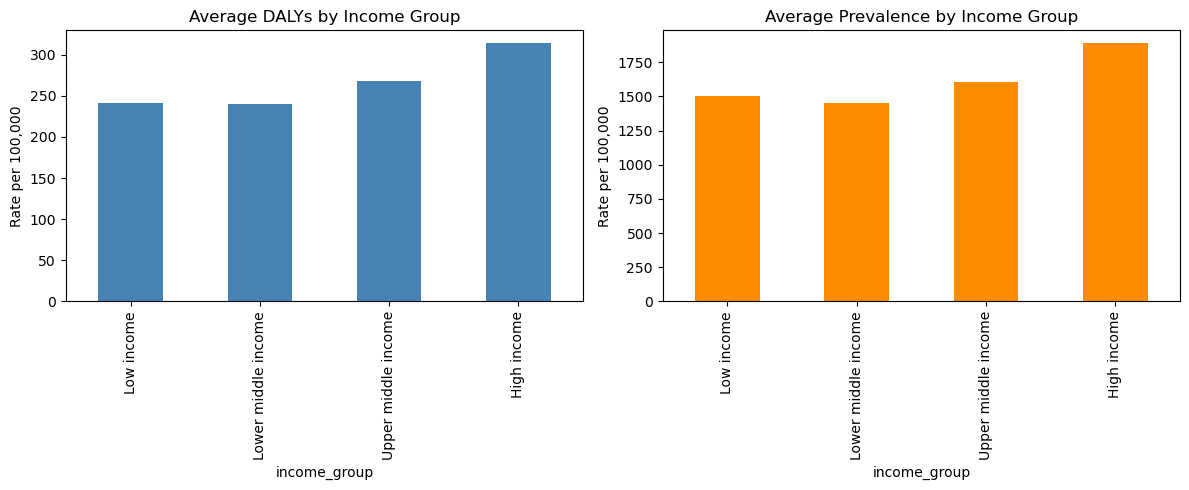

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']

pivot['DALYs (Disability-Adjusted Life Years)'].reindex(order).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average DALYs by Income Group')
axes[0].set_ylabel('Rate per 100,000')

pivot['Prevalence'].reindex(order).plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Average Prevalence by Income Group')
axes[1].set_ylabel('Rate per 100,000')

plt.tight_layout()
plt.show()

Both measures follow the same pattern across income groups. Plotting them together 
now gives a combined view for comparison, keeping in mind DALYs and Prevalence are 
on different scales.

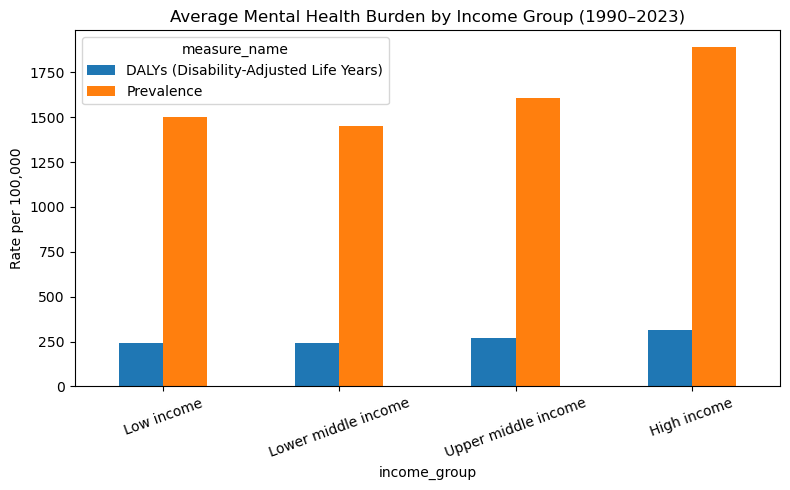

In [19]:
import matplotlib.pyplot as plt

pivot = income_summary.pivot(index='income_group', columns='measure_name', values='val')
pivot = pivot.reindex(['Low income', 'Lower middle income', 'Upper middle income', 'High income'])

pivot.plot(kind='bar', figsize=(8,5))
plt.title('Average Mental Health Burden by Income Group (1990–2023)')
plt.ylabel('Rate per 100,000')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### What This Shows

Both prevalence and DALYs follow the same pattern across income groups — highest 
in High income countries, lowest in Lower-middle income, with a slight rise again 
in Low income. This means income level does relate to mental health burden, but 
not in a simple "richer = healthier" way. High-income countries actually show the 
highest burden by both measures, likely due to better diagnosis and reporting 
systems, less stigma around seeking help, and possibly different lifestyle-related 
stressors — while lower-income countries may under-report due to limited healthcare 
access and diagnosis infrastructure, rather than genuinely having less burden.

### Burden by Income Group and Disorder Type

Checking whether the income-group pattern holds across all 5 disorders, or if 
some disorders behave differently.

In [20]:
disorder_summary = df[df['measure_name']=='Prevalence'].groupby(['income_group', 'cause_name'])['val'].mean().reset_index()
disorder_pivot = disorder_summary.pivot(index='cause_name', columns='income_group', values='val')
disorder_pivot = disorder_pivot[['Low income', 'Lower middle income', 'Upper middle income', 'High income']]
disorder_pivot

income_group,Low income,Lower middle income,Upper middle income,High income
cause_name,,,,
Anxiety disorders,3943.868074,3666.581439,4085.275957,4786.328389
Bipolar disorder,360.840426,406.449418,530.380144,658.666342
Depressive disorders,2886.941341,2764.461124,2900.374410,3266.341317
Eating disorders,115.954510,166.664502,237.507742,388.248065
Schizophrenia,205.129453,242.085859,294.252377,350.223892


Breaking the pattern down by disorder type reveals more detail. High income is 
consistently the highest across all 5 disorders — that part of the pattern is 
very solid. But the lower/middle income tiers don't move in a straight line for 
every disorder: Anxiety and Depression both dip at Lower-middle income before 
rising again, while Bipolar disorder, Eating disorders, and Schizophrenia increase 
steadily from Low to High income with no dip.

Since Anxiety and Depression have much larger values than the other three disorders, 
they dominate the overall combined average — which explains why the earlier overall 
chart also showed a dip at Lower-middle income. That dip isn't representative of all 
5 disorders equally; it mainly reflects the pattern in just Anxiety and Depression, 
the two largest contributors to the average.

### Selecting Spotlight Countries

Rather than picking countries arbitrarily, checking which country in each income 
group is closest to that group's average burden — a representative example for 
the dashboard's country-level story.

In [21]:
prevalence_df = df[df['measure_name'] == 'Prevalence']

country_avg = prevalence_df.groupby(['income_group', 'location_name'])['val'].mean().reset_index()

group_avg = country_avg.groupby('income_group')['val'].transform('mean')
country_avg['diff_from_group_avg'] = (country_avg['val'] - group_avg).abs()

spotlight = country_avg.loc[country_avg.groupby('income_group')['diff_from_group_avg'].idxmin()]
spotlight

,income_group,location_name,val,diff_from_group_avg
59,High income,Slovenia,1895.845444,5.883843
85,Low income,Mozambique,1481.230528,21.316233
107,Lower middle income,Eswatini,1449.050868,0.197601
181,Upper middle income,North Macedonia,1604.738688,4.819439


The countries closest to each group's average (Slovenia, Mozambique, Eswatini, 
North Macedonia) are statistically the most representative, but they're not widely 
recognized names for a general audience. Since this dashboard is meant to be 
relatable as well as accurate, checking a shortlist of the closest-to-average 
countries per group, so a more globally familiar country can be chosen instead — 
as long as it doesn't stray far from the group average.

In [22]:
shortlist = country_avg.sort_values(['income_group', 'diff_from_group_avg']).groupby('income_group').head(8)
shortlist

,income_group,location_name,val,diff_from_group_avg
59,High income,Slovenia,1895.845444,5.883843
67,High income,United States Virgin Islands,1926.795611,36.834010
31,High income,Italy,1849.020072,40.941529
15,High income,Croatia,1848.193526,41.768075
30,High income,Israel,1847.414911,42.546690
61,High income,Sweden,1842.924475,47.037126
55,High income,Saudi Arabia,1950.003035,60.041434
64,High income,Trinidad and Tobago,1820.904086,69.057515
85,Low income,Mozambique,1481.230528,21.316233
80,Low income,Guinea-Bissau,1553.964491,51.417730


Checking a few very well-known countries (USA, UK, Japan, South Korea) to see if 
they could work as spotlight countries instead, since they're more globally 
recognizable than the earlier shortlist.

In [12]:
check_countries = ['United States of America', 'United Kingdom', 'Japan', 'Republic of Korea']
country_avg[country_avg['location_name'].isin(check_countries)]

,income_group,location_name,val,diff_from_group_avg
32,High income,Japan,1326.505396,563.456205
50,High income,Republic of Korea,1570.208961,319.752640
66,High income,United Kingdom,2557.176711,667.215110
68,High income,United States of America,2320.896852,430.935251


These four countries are all far from their income group's average — much further 
than anything in the earlier shortlist. Interestingly, they split in opposite 
directions: the UK and USA sit well above the High income average, while Japan and 
South Korea sit well below it. This shows there's real variation even within the 
same income group, which is worth mentioning separately — but it means none of these 
four are good "typical representative" picks. Sticking with the earlier shortlist 
for the main spotlight countries instead.

### Final Spotlight Countries

Balancing statistical representativeness with global recognizability, the following 
countries are selected as spotlights — each reasonably close to their income group's 
average, while also being widely known:

- High income: Italy
- Upper middle income: Mexico
- Lower middle income: India
- Low income: Mali

In [23]:
spotlight_countries = ['Italy', 'Mexico', 'India', 'Mali']
country_avg[country_avg['location_name'].isin(spotlight_countries)]

,income_group,location_name,val,diff_from_group_avg
31,High income,Italy,1849.020072,40.941529
84,Low income,Mali,1436.732031,65.814730
112,Lower middle income,India,1351.247542,98.000926
177,Upper middle income,Mexico,1626.529300,16.971173


In [24]:
high_income_range = country_avg[country_avg['income_group']=='High income'].sort_values('val')
print("Lowest in High income:", high_income_range.iloc[0][['location_name','val']].values)
print("Highest in High income:", high_income_range.iloc[-1][['location_name','val']].values)

Lowest in High income: ['Seychelles' np.float64(964.6525151459855)]
Highest in High income: ['Portugal' np.float64(2858.702948777239)]


### Side Note: Variation Within Income Groups

Even within the same income group, countries can vary a lot. Among High income 
countries, Seychelles has the lowest average prevalence (965) while Portugal has 
the highest (2859) — almost a 3x difference. This shows income group captures a 
useful broad pattern, but doesn't mean every country within a group behaves 
identically; other factors clearly play a role too.

### What This Variation Means for the Overall Insight

The income-group averages still show a real, meaningful pattern — but the within-group 
variation (like Portugal vs. Seychelles both being "High income" yet nearly 3x apart) 
shows income level is only a partial explanation. It doesn't fully determine mental 
health burden on its own; other factors like healthcare access, cultural attitudes 
toward diagnosis, and reporting practices likely also play a role. The main insight 
should be framed carefully: income relates to mental health burden at a broad, 
group level, but it isn't the whole story.

## Trend Over Time by Income Group

Checking how mental health burden has changed from 1990 to 2023 across income 
groups — has the gap between groups widened, narrowed, or stayed consistent?

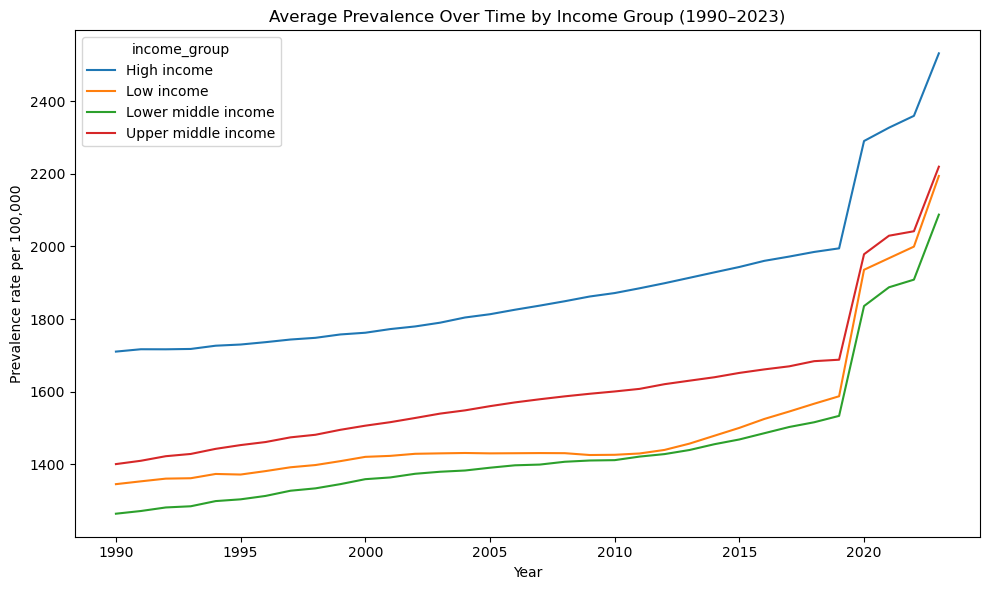

In [25]:
trend = df[df['measure_name']=='Prevalence'].groupby(['year', 'income_group'])['val'].mean().reset_index()
trend_pivot = trend.pivot(index='year', columns='income_group', values='val')
trend_pivot.plot(figsize=(10,6))
plt.title('Average Prevalence Over Time by Income Group (1990–2023)')
plt.ylabel('Prevalence rate per 100,000')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

The trend over time reveals a few clear patterns:

1. The ranking between income groups has stayed consistent for over 30 years - High 
income has had the highest prevalence the entire time, while Low, Lower-middle, and 
Upper-middle income stay much closer to each other throughout.

2. All four groups show a sharp jump starting around 2019-2020 - very likely linked 
to COVID-19, which is well documented to have caused a global spike in anxiety and 
depression due to isolation, economic stress, and disrupted healthcare access.

3. High income's gap from the other three groups doesn't close after the pandemic 
spike - the relative ranking between income groups stayed the same before and after, 
even though every group's burden increased.

### Trend Over Time by Disorder Type

Checking whether each disorder followed the same overall pattern (steady rise + 
COVID-era jump), or if some disorders — like Anxiety and Depression, which are often 
linked most directly to pandemic-related stress — drove the spike more than others.

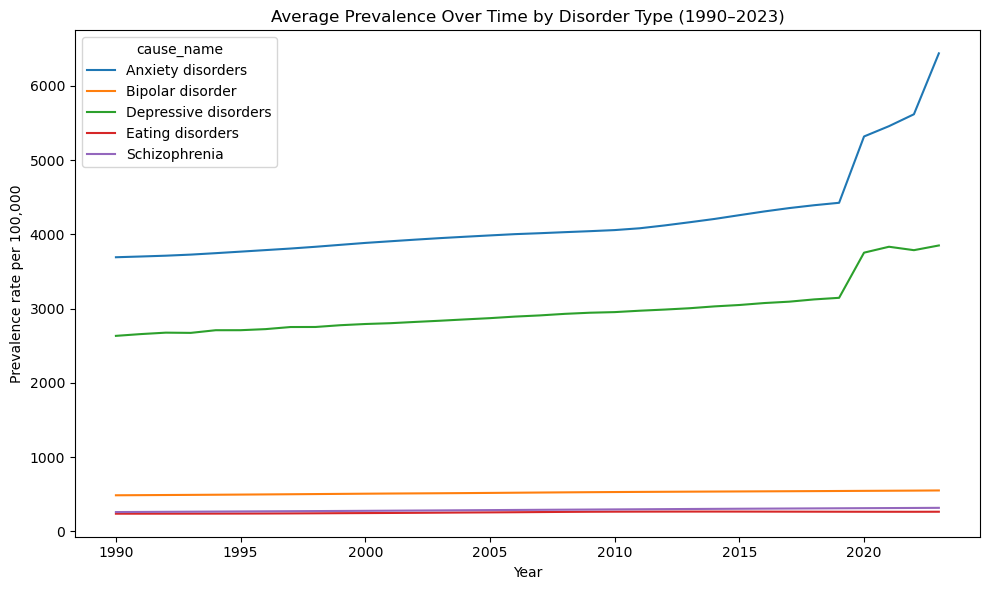

In [26]:
disorder_trend = df[df['measure_name']=='Prevalence'].groupby(['year', 'cause_name'])['val'].mean().reset_index()
disorder_trend_pivot = disorder_trend.pivot(index='year', columns='cause_name', values='val')

disorder_trend_pivot.plot(figsize=(10,6))
plt.title('Average Prevalence Over Time by Disorder Type (1990–2023)')
plt.ylabel('Prevalence rate per 100,000')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

The trend over time by disorder type reveals a few clear patterns:

1. Eating disorders, Schizophrenia, and Bipolar disorder stayed essentially flat 
over the full 30 years, showing no visible reaction to COVID-19 - consistent with 
the earlier finding that these are smaller, more stable disorders less tied to 
acute situational stress

2. Anxiety and Depression increased only gradually before 2020, then both spiked 
sharply around 2020 -confirming these two disorders drove the overall combined-
average jump seen earlier.


4. After the spike, Anxiety and Depression diverge: Anxiety keeps climbing steadily 
at a faster rate than before, suggesting a lasting shift to a higher baseline, while 
Depression's rate dips slightly and becomes inconsistent after 2021, suggesting more 
of a temporary shock that partially receded rather than a permanent change.

### Spotlight Countries: Individual Trends Over Time

Checking how each of the 4 spotlight countries (Italy, Mexico, India, Mali) has 
trended over 1990–2023, to see if they follow their income group's overall pattern 
or show their own distinct story.

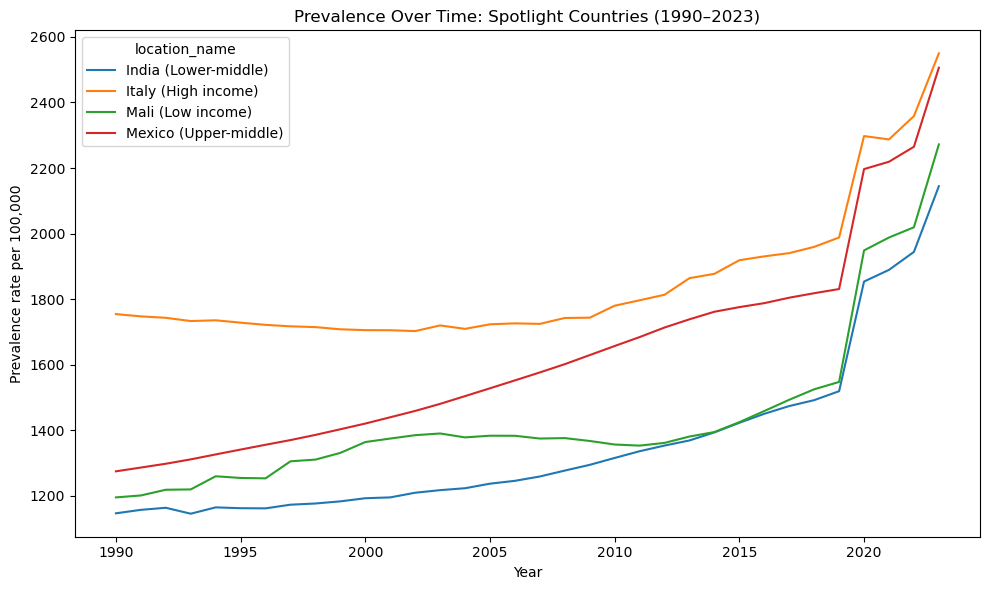

In [27]:
spotlight_trend = df[(df['measure_name']=='Prevalence') & (df['location_name'].isin(['Italy','Mexico','India','Mali']))]
spotlight_trend_pivot = spotlight_trend.pivot_table(index='year', columns='location_name', values='val')

label_map = {'Italy': 'Italy (High income)', 'Mexico': 'Mexico (Upper-middle)', 
             'India': 'India (Lower-middle)', 'Mali': 'Mali (Low income)'}
spotlight_trend_pivot = spotlight_trend_pivot.rename(columns=label_map)

spotlight_trend_pivot.plot(figsize=(10,6))
plt.title('Prevalence Over Time: Spotlight Countries (1990–2023)')
plt.ylabel('Prevalence rate per 100,000')
plt.xlabel('Year')
plt.tight_layout()
plt.show()


Each spotlight country clearly reflects its income group's overall pattern:

1. Italy (High income) stays highest throughout the full 34 years, confirming it 
represents its group well.
2. All four countries show the same COVID-era spike around 2020, consistent with 
the earlier income-group and disorder-level findings.
3. Mexico (Upper-middle income) gradually closes the gap with Italy over time — 
by the late 2010s it's noticeably closer to Italy's line than it was in 1990 — 
while Mali and India stay much further below Italy throughout, never closing that gap.
4. Mali (Low income) and India (Lower-middle income) track closely together for 
most of the period, but cross over around 2011-2012: before that point Mali is 
higher, and after it India overtakes Mali and stays higher for the rest of the 
period, with the gap widening further after 2020.
5. After the 2020 spike, the overall ranking stays the same — Italy remains highest, 
confirming income level's relationship with mental health burden held steady even 
through the pandemic disruption.

### Note on Population Size and Comparability

Since these countries vary hugely in population (India ~1.4 billion vs. Mali ~22 
million), it's worth confirming this comparison is still fair. It is — the `val` 
column represents a rate per 100,000 people, not a raw count, so it measures how 
common a disorder is relative to population size, not how many total people are 
affected. This means differences in population size don't distort the comparison 
between countries or income groups.

### Exporting Data for Power BI

Exporting a few clean, aggregated CSVs so Power BI can build visuals directly 
without needing heavy transformation.

In [28]:
# 1. Income group summary (for overall comparison chart)
income_summary.to_csv(r"C:\Users\ASUS\Documents\Mental Health Dashboard\exports\income_group_summary.csv", index=False)

# 2. Disorder x income group breakdown
disorder_summary.to_csv(r"C:\Users\ASUS\Documents\Mental Health Dashboard\exports\disorder_by_income.csv", index=False)

# 3. Trend over time by income group
trend.to_csv(r"C:\Users\ASUS\Documents\Mental Health Dashboard\exports\trend_by_income_group.csv", index=False)

# 4. Trend over time by disorder
disorder_trend.to_csv(r"C:\Users\ASUS\Documents\Mental Health Dashboard\exports\trend_by_disorder.csv", index=False)

# 5. Spotlight countries trend
spotlight_trend.to_csv(r"C:\Users\ASUS\Documents\Mental Health Dashboard\exports\spotlight_countries_trend.csv", index=False)

print("All exports saved.")

All exports saved.


### Export: World Map with Year Slicer

Exporting country-level prevalence data across all years, so the 
map can be paired with a year slicer for interactive exploration.

In [29]:
map_data_all_years = df[df['measure_name']=='Prevalence'].groupby(['year', 'location_name', 'income_group'])['val'].mean().reset_index()
map_data_all_years.to_csv(r"C:\Users\ASUS\Documents\Mental Health Dashboard\exports\map_data_all_years.csv", index=False)
print(map_data_all_years.shape)

(6800, 4)
